(01-04-markowitz)=

# Markowitz, Roy en Tobin

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1952–1959.

**Wat we al weten.** Uit [](#01-03-williams-ddm) komt een theorie van het
*niveau* van een prijs: een aandeel is de contante waarde van zijn dividenden,
verdisconteerd tegen een voet $r$. Die identiteit legt vast dat prijzen alleen
kunnen bewegen doordat verwachte uitkeringen bewegen of doordat $r$ beweegt, en
de replicatie daar liet zien dat het vooral $r$ is. Maar Williams had geen enkele
theorie van $r$: hij nam de discontovoet als gegeven en zei niet waar hij vandaan
kwam, en hij bekeek elk aandeel apart, alsof een belegger één ding koopt in
plaats van een portefeuille.

**Welke vraag staat open.** Wat is het risico van een belegging — het risico van
dat ene stuk papier, of wat het toevoegt aan de portefeuille die u toch al
houdt?
```

## Overzicht

In maart 1952 verscheen in *The Journal of Finance* een artikel van veertien
pagina's van een promovendus aan de Universiteit van Chicago
{cite}`Markowitz1952`. Het bevatte vier grafieken, geen data, en één idee: een
belegger geeft om twee grootheden, de verwachting en de variantie van zijn
portefeuillerendement, en die twee samen bepalen welke portefeuilles überhaupt
in aanmerking komen. Vier maanden later, in juli, publiceerde A. D. Roy in
*Econometrica* een artikel dat vanuit een heel ander principe — minimaliseer de
kans op een ramp — bij vrijwel dezelfde meetkunde uitkwam {cite}`Roy1952`. Zes
jaar later voegde James Tobin het risicovrije activum toe en liet zien dat de
samenstelling van het risicovolle deel dan voor iedereen hetzelfde is
{cite}`Tobin1958`. In 1959 werkte Markowitz het geheel uit tot een boek met
rekenrecepten {cite}`Markowitz1959`.

Dat werk definieert het tijdvak omdat het de vraag verplaatst. Williams vroeg
wat een aandeel waard is; Markowitz vraagt welke portefeuille u wilt houden, en
laat zien dat het antwoord op die vraag de eerste vraag verandert. Het risico van
een activum is niet zijn eigen variantie maar zijn covariantie met de rest van wat
u bezit. Die ene verschuiving — van variantie naar covariantie — is de kiem van
het CAPM, van elk factormodel en van de hele moderne cross-sectie. De
epistemische status van het resultaat is die van een *theorie van keuze*, niet
van een toetsbare uitspraak over prijzen: Markowitz zegt wat een belegger zou
moeten doen gegeven $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$, niet wat de
markt doet. Pas wanneer iedereen dit doet en de markt moet ruimen, wordt het een
uitspraak over prijzen — en dat is [](#02-08-capm).

Tegelijk brengt deze lecture de eerste echte confrontatie met het 2%-motief. De
oplossing van Markowitz is een functie van $\boldsymbol{\mu}$ en
$\boldsymbol{\Sigma}$, en die kennen we niet: we schatten ze. De theorie is
exact, de invoer is dat niet, en het resultaat is een portefeuille die
er in de steekproef schitterend uitziet en buiten de steekproef vaak slechter is
dan het gelijk verdelen van uw geld over alle activa. We repliceren dat aan het
eind op de industrieportefeuilles en de 25 size/BM-portefeuilles van French,
volgens het recept van {cite:t}`DeMiguelGarlappiUppal2009`.

De imports-cel hieronder staat in elke lecture bovenaan en bevat alle imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Stel u bezit één aandeel en overweegt er een tweede bij te kopen. De vraag die
iedereen vóór 1952 stelde was: hoe riskant is dat tweede aandeel? De vraag die
Markowitz stelde was: hoe riskant wordt mijn portefeuille? Dat zijn niet dezelfde
vragen, en het verschil is groter dan het lijkt.

Neem twee aandelen die allebei even veel op en neer gaan, maar nooit tegelijk.
Elk apart is riskant. Samen, half om half, is de portefeuille aanzienlijk
rustiger: waar de een verliest, wint de ander vaak. Neem nu twee aandelen die
allebei even veel op en neer gaan en dat altijd tegelijk doen. Samen zijn ze
precies even riskant als elk apart — er valt niets te winnen. De twee gevallen
zijn ononderscheidbaar als u alleen naar de afzonderlijke aandelen kijkt. Wat ze
onderscheidt is hun onderlinge beweging, en die staat niet in de eigenschappen
van de aandelen maar in de relatie ertussen.

Daarmee is diversificatie niet "verdeel uw geld over veel dingen" maar iets
scherpers: *diversificatie is het beheer van covariantie*. Dat is geen
woordspelletje. Een portefeuille van honderd aandelen die allemaal dezelfde
bank zijn, is niet gediversifieerd; een portefeuille van drie activa die niets
met elkaar te maken hebben, is dat wel. Het aantal doet er alleen toe voor zover
het de gemiddelde covariantie verlaagt. En daaruit volgt meteen de belangrijkste
consequentie, die de rest van deze reeks draagt: als u al een goed gespreide
portefeuille houdt, dan is de bijdrage van een extra aandeel aan uw risico
volledig bepaald door zijn covariantie met wat u al hebt. De eigen variantie van
dat aandeel — het deel dat niets met de rest te maken heeft — verdwijnt in de
massa. En iets wat verdwijnt, hoeft niemand te compenseren.

Markowitz kwam op het idee, zo vertelde hij later, in de leeszaal van de
bibliotheek van de business school in Chicago, met het boek van Williams in
handen {cite}`Markowitz1999`. Als de waarde van een aandeel de contante waarde is
van zijn verwachte dividenden, redeneerde hij, dan zou een belegger die alleen
om verwachtingen geeft alles in het ene aandeel met het hoogste verwachte
rendement moeten stoppen. Dat doet niemand, en dat is geen dwaasheid van de
praktijk maar een gat in de theorie: er ontbreekt een tweede grootheid. Die
tweede grootheid werd de variantie, en zodra er twee grootheden zijn, is er een
afruil en een verzameling van portefeuilles die niet te verslaan zijn — de
*efficient frontier* (efficiënte rand: de portefeuilles met de laagste variantie
bij elk gegeven verwacht rendement).

```{note}
Bij de verdediging van zijn proefschrift, vertelt Markowitz in de heruitgave van
zijn boek uit 1959, zei Milton Friedman: *"I've read your dissertation and can't
find any mistakes in it. There is just one problem: this is not a dissertation in
economics. We cannot award you a Ph.D. in economics for a dissertation that is
not economics."* Markowitz kreeg de graad diezelfde dag
{cite}`KleinDazaMead2013`. De anekdote is meer dan kleur: portefeuillekeuze wás
in 1952 geen economie. Er was geen markt in het model, geen evenwicht, geen
prijs — alleen een beslissingsprobleem. Dat het toch economie werd, is precies
wat er in het volgende decennium gebeurde.
```

Roy kwam via een andere deur binnen. Zijn belegger geeft niet om variantie maar
om ondergang: hij wil de kans minimaliseren dat zijn rendement onder een
rampniveau $d$ zakt. Roy had in de oorlog gediend en schreef, naar eigen zeggen,
voor mensen voor wie een slechte uitkomst niet een tegenvaller is maar het
einde. Maar wie die kans wil begrenzen zonder de verdeling te kennen, komt bij de
ongelijkheid van Bienaymé-Tchebycheff uit, en die zegt dat de kans op een ramp
klein is zodra $(\mu_p - d)/\sigma_p$ groot is. Minimaliseer de ondergangskans en
u maximaliseert een ratio van verwachting en standaarddeviatie — dezelfde
meetkunde, uit een heel ander motief. Dat een principe van voorzichtigheid en een
principe van nutsmaximalisatie in hetzelfde punt eindigen, is de reden dat de
uitkomst zo lang is blijven staan.

Tobin voegde de laatste steen toe. Zodra er één activum is dat zeker is — een
schatkistpapier — kiest u eerst de beste *verhouding* tussen verwachting en
risico onder de risicovolle activa, en pas daarna hoeveel van uw vermogen u
daarin stopt. Wie voorzichtig is, houdt meer contanten; wie agressief is, leent
bij. Maar de samenstelling van het risicovolle mandje is voor allebei identiek.
Dat is de *separatiestelling*, en ze is de reden dat de zin "de markt is de
optimale portefeuille" überhaupt betekenis kan krijgen.

## Toy-voorbeeld: drie activa, één 3×3-covariantiematrix

Het kleinste geval waarin alles al zichtbaar is, heeft drie activa. Neem ze
jaarlijks, en lees ze als aandelen (A), kleine aandelen (B) en obligaties (C):

| Activum | $\mu_i$ | $\sigma_i$ | $\Corr$ met A | $\Corr$ met B | $\Corr$ met C |
|---|---|---|---|---|---|
| A (aandelen) | 10{,}0% | 20{,}0% | 1 | 1/3 | 0 |
| B (kleine aandelen) | 14{,}0% | 30{,}0% | 1/3 | 1 | 0 |
| C (obligaties) | 4{,}0% | 10{,}0% | 0 | 0 | 1 |

De covariantiematrix volgt uit $\Sigma_{ij} = \rho_{ij}\sigma_i\sigma_j$. Met
$\rho_{AB} = 1/3$ is $\Sigma_{AB} = (1/3)(0{,}20)(0{,}30) = 0{,}02$:

$$
\boldsymbol{\mu} =
\begin{pmatrix} 0{,}10 \\ 0{,}14 \\ 0{,}04 \end{pmatrix},
\qquad
\boldsymbol{\Sigma} =
\begin{pmatrix}
0{,}04 & 0{,}02 & 0 \\
0{,}02 & 0{,}09 & 0 \\
0 & 0 & 0{,}01
\end{pmatrix}.
$$

Omdat C met niets correleert, valt $\boldsymbol{\Sigma}$ uiteen in een
$2\times2$-blok en een scalair. De determinant van het blok is
$0{,}04 \cdot 0{,}09 - 0{,}02^2 = 0{,}0036 - 0{,}0004 = 0{,}0032$, dus

$$
\boldsymbol{\Sigma}^{-1} =
\begin{pmatrix}
28{,}125 & -6{,}25 & 0 \\
-6{,}25 & 12{,}5 & 0 \\
0 & 0 & 100
\end{pmatrix}.
$$

Let op het teken buiten de diagonaal: de inverse covariantiematrix heeft een
*negatieve* entry waar de covariantie positief is. Dat is de hele theorie in één
getal — de optimalisatie zet twee activa die samen bewegen tegen elkaar in.

Nu de drie getallen waar alles uit volgt. Met $\mathbf{1} = (1,1,1)'$:

$$
\begin{aligned}
\boldsymbol{\Sigma}^{-1}\mathbf{1} &= (21{,}875,\; 6{,}25,\; 100)', \\
\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} &= (1{,}9375,\; 1{,}125,\; 4)'.
\end{aligned}
$$

Daaruit
$A = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1} = 21{,}875 + 6{,}25 + 100 = 128{,}125$,
$B = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} = 1{,}9375 + 1{,}125 + 4 = 7{,}0625$
en
$C = \boldsymbol{\mu}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}
= 0{,}10(1{,}9375) + 0{,}14(1{,}125) + 0{,}04(4) = 0{,}51125$.
De discriminant is

$$
D = AC - B^2 = 128{,}125 \cdot 0{,}51125 - 7{,}0625^2
= 65{,}50390625 - 49{,}87890625 = 15{,}625 .
$$

**De minimum-variantieportefeuille.** Zij is
$\mathbf{w}_{\mathrm{mv}} = \boldsymbol{\Sigma}^{-1}\mathbf{1}/A$, dus

$$
\mathbf{w}_{\mathrm{mv}} = \frac{1}{128{,}125}\,(21{,}875,\; 6{,}25,\; 100)'
= \left(\tfrac{7}{41},\; \tfrac{2}{41},\; \tfrac{32}{41}\right)'
= (0{,}1707,\; 0{,}0488,\; 0{,}7805)' .
$$

Haar verwachte rendement is $\mu_{\mathrm{mv}} = B/A = 7{,}0625/128{,}125 =
5{,}5122\%$ en haar variantie $\sigma^2_{\mathrm{mv}} = 1/A = 1/128{,}125 =
0{,}0078049$, dus $\sigma_{\mathrm{mv}} = 8{,}8345\%$. Dat laatste getal is het
eerste resultaat van de hele theorie: de veiligste haalbare portefeuille is
*veiliger dan het veiligste activum*. Obligaties alleen geven 10,0%
standaarddeviatie; een mengsel met 22% in twee aandelenposities geeft 8,83%.
Riskante dingen toevoegen maakt het geheel minder riskant, omdat ze niet met C
meebewegen.

**De frontier.** De variantie van de efficiënte portefeuille met verwacht
rendement $\mu_p$ is (dit leiden we hieronder af)

$$
\sigma^2(\mu_p) = \frac{A\mu_p^2 - 2B\mu_p + C}{D} .
$$

Bij $\mu_p = 0{,}10$ geeft dat
$(128{,}125 \cdot 0{,}01 - 2 \cdot 7{,}0625 \cdot 0{,}10 + 0{,}51125)/15{,}625
= (1{,}28125 - 1{,}4125 + 0{,}51125)/15{,}625 = 0{,}38/15{,}625 = 0{,}024320$,
dus $\sigma = 15{,}595\%$. Activum A alléén levert hetzelfde verwachte rendement
van 10% met een standaarddeviatie van 20%. De efficiënte portefeuille met
hetzelfde verwachte rendement heeft dus ruim een vijfde minder risico, zonder
dat er ergens een rendement is bijverzonnen.

**De tangentportefeuille.** Voeg een risicovrije rente $R^{f} - 1 = 2{,}0\%$ toe.
De portefeuille met de hoogste Sharpe-ratio is evenredig met
$\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - R^{f}\mathbf{1})$, en met
$\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} - 0{,}02\,\boldsymbol{\Sigma}^{-1}\mathbf{1}
= (1{,}9375 - 0{,}4375,\; 1{,}125 - 0{,}125,\; 4 - 2)' = (1{,}5,\; 1{,}0,\; 2{,}0)'$
en normalisatie $B - R^{f}A = 7{,}0625 - 2{,}5625 = 4{,}5$:

$$
\mathbf{w}_{\mathrm{tan}} = \frac{1}{4{,}5}(1{,}5,\; 1{,}0,\; 2{,}0)'
= \left(\tfrac13,\; \tfrac29,\; \tfrac49\right)'
= (0{,}3333,\; 0{,}2222,\; 0{,}4444)'.
$$

Haar verwachte rendement is $\tfrac13(0{,}10) + \tfrac29(0{,}14) + \tfrac49(0{,}04)
= 8{,}2222\%$, dus een risicopremie van 6,2222 procentpunt. Het kwadraat van de
maximale Sharpe-ratio is
$C - 2R^{f}B + (R^{f})^2 A = 0{,}51125 - 0{,}2825 + 0{,}05125 = 0{,}28$,
dus de maximale Sharpe-ratio is $\sqrt{0{,}28} = 0{,}52915$ en
$\sigma_{\mathrm{tan}} = 0{,}062222/0{,}52915 = 11{,}759\%$.

Merk op wat er met B gebeurt. Activum B heeft het hoogste verwachte rendement en
verreweg het hoogste risico, en krijgt in de tangentportefeuille maar 22,2% —
minder dan het saaie C. Niet omdat B slecht is, maar omdat B met A meebeweegt en
daarom weinig toevoegt aan wat A al levert.

De codecel reproduceert alle getallen uit de handberekening.

In [2]:
mu = np.array([0.10, 0.14, 0.04])
sd = np.array([0.20, 0.30, 0.10])
corr = np.array([[1.0, 1 / 3, 0.0],
                 [1 / 3, 1.0, 0.0],
                 [0.0, 0.0, 1.0]])
Sigma = corr * np.outer(sd, sd)
ones = np.ones(3)
rf = 0.02

Sinv_1, Sinv_mu = np.linalg.solve(Sigma, ones), np.linalg.solve(Sigma, mu)
A, B, C = ones @ Sinv_1, ones @ Sinv_mu, mu @ Sinv_mu
D = A * C - B**2

w_mv = Sinv_1 / A
w_tan = (Sinv_mu - rf * Sinv_1) / (B - rf * A)
sharpe_max = np.sqrt(C - 2 * rf * B + rf**2 * A)

pd.DataFrame(
    {
        "waarde": [A, B, C, D, B / A, np.sqrt(1 / A),
                   np.sqrt((A * 0.10**2 - 2 * B * 0.10 + C) / D),
                   w_tan @ mu, np.sqrt(w_tan @ Sigma @ w_tan), sharpe_max],
    },
    index=["A", "B", "C", "D", "mu van min-var", "sigma van min-var",
           "sigma van de frontier bij mu = 10%", "mu van de tangentportefeuille",
           "sigma van de tangentportefeuille", "maximale Sharpe-ratio"],
).round(6)

,waarde
A,128.125000
B,7.062500
C,0.511250
D,15.625000
mu van min-var,0.055122
sigma van min-var,0.088345
sigma van de frontier bij mu = 10%,0.155949
mu van de tangentportefeuille,0.082222
sigma van de tangentportefeuille,0.117589
maximale Sharpe-ratio,0.529150


In [3]:
pd.DataFrame(
    {"minimum-variantie": w_mv, "tangent": w_tan},
    index=["A aandelen", "B kleine aandelen", "C obligaties"],
).round(6)

,minimum-variantie,tangent
A aandelen,0.170732,0.333333
B kleine aandelen,0.048780,0.222222
C obligaties,0.780488,0.444444


$A = 128{,}125$, $B = 7{,}0625$, $C = 0{,}51125$, $D = 15{,}625$, gewichten
$(7/41, 2/41, 32/41)$ en $(1/3, 2/9, 4/9)$, Sharpe $0{,}529150$ — de code geeft
tot op zes decimalen dezelfde getallen als de handberekening hierboven. Dat is
de reden dat u de rest van de code in deze lecture mag vertrouwen.

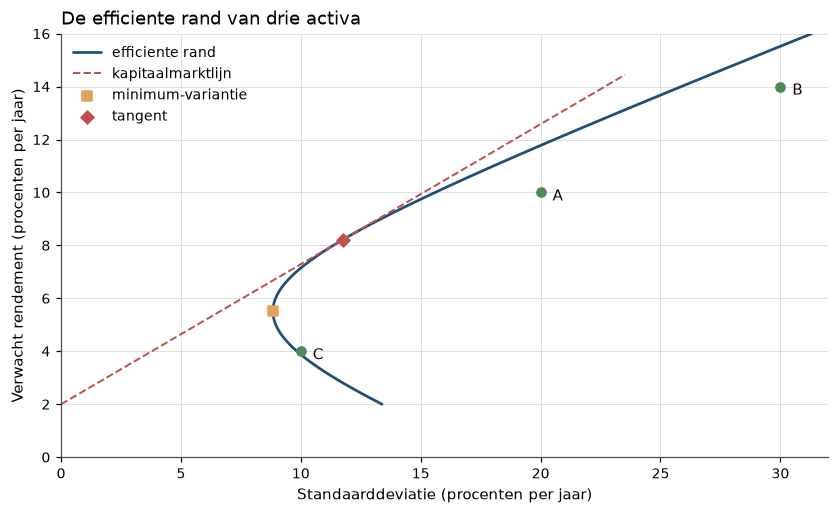

In [4]:
grid = np.linspace(0.02, 0.16, 400)
sigma_frontier = np.sqrt((A * grid**2 - 2 * B * grid + C) / D)

fig, ax = plt.subplots()
ax.plot(sigma_frontier * 100, grid * 100, lw=1.8, label="efficiente rand")
ax.plot([0, np.sqrt(w_tan @ Sigma @ w_tan) * 200],
        [rf * 100, rf * 100 + sharpe_max * np.sqrt(w_tan @ Sigma @ w_tan) * 200],
        ls="--", lw=1.3, color=hap.plotting.COLORS[1],
        label="kapitaalmarktlijn")
ax.scatter(sd * 100, mu * 100, zorder=3, color=hap.plotting.COLORS[2])
for name, s, m in zip(["A", "B", "C"], sd, mu):
    ax.annotate(name, (s * 100 + 0.5, m * 100 - 0.3))
ax.scatter([np.sqrt(1 / A) * 100], [B / A * 100], marker="s", zorder=3,
           color=hap.plotting.COLORS[3], label="minimum-variantie")
ax.scatter([np.sqrt(w_tan @ Sigma @ w_tan) * 100], [(w_tan @ mu) * 100],
           marker="D", zorder=3, color=hap.plotting.COLORS[1], label="tangent")
ax.set_xlim(0, 32)
ax.set_ylim(0, 16)
ax.set_xlabel("Standaarddeviatie (procenten per jaar)")
ax.set_ylabel("Verwacht rendement (procenten per jaar)")
ax.set_title("De efficiente rand van drie activa")
ax.legend()
plt.show()

:::{figure} #cel-markowitz-frontier
:label: fig-markowitz-frontier
:width: 90%

De drie activa (punten), de efficiënte rand en de kapitaalmarktlijn vanaf de
risicovrije rente van 2%. Elk afzonderlijk activum ligt rechts van de rand: er
is telkens een mengsel met hetzelfde verwachte rendement en minder risico. De
minimum-variantieportefeuille (vierkant) ligt met 8,83% links van het veiligste
activum, dat 10,0% heeft. Het raakpunt (ruit) is de enige portefeuille die de
kapitaalmarktlijn haalt.
:::

## Theorie

### Opzet en notatie

Er zijn $N$ risicovolle activa met bruto rendementen $\mathbf{R}_{t+1}$,
verwachting $\boldsymbol{\mu} = \E[\mathbf{R}_{t+1}]$ en covariantiematrix
$\boldsymbol{\Sigma} = \Var(\mathbf{R}_{t+1})$, die we positief definiet
veronderstellen — geen activum is een exacte combinatie van de andere. Een
portefeuille is een gewichtsvector $\mathbf{w} \in \mathbb{R}^N$ met
$\mathbf{w}'\mathbf{1} = 1$; negatieve gewichten (short posities) zijn
toegestaan. Haar rendement is $R_{p,t+1} = \mathbf{w}'\mathbf{R}_{t+1}$, met

$$
\mu_p = \mathbf{w}'\boldsymbol{\mu}, \qquad
\sigma_p^2 = \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
= \sum_{i}\sum_{j} w_i w_j \Cov(R_i, R_j).
$$

Markowitz zelf schrijft $E$ en $V$ waar wij $\mu_p$ en $\sigma_p^2$ schrijven,
en werkt met enkelvoudige rendementen in plaats van bruto rendementen; dat
verandert niets aan de wiskunde, omdat een constante van alle rendementen
aftrekken de covariantiematrix onveranderd laat.

Waarom zou een belegger *alleen* om $\mu_p$ en $\sigma_p^2$ geven? Er zijn twee
rechtvaardigingen, en geen van beide is onschuldig. Ofwel de rendementen zijn
multivariaat normaal verdeeld, zodat de hele verdeling van $R_p$ door die twee
momenten is bepaald; ofwel het nut is kwadratisch,
$u(W) = W - \tfrac{b}{2}W^2$, want dan hangt $\E[u]$ per constructie alleen van
de eerste twee momenten af. Normaliteit is empirisch onjuist (dikke staarten),
kwadratisch nut theoretisch onaangenaam (toenemende absolute risicoaversie).
Mean-variance is daarom een tweede-orde benadering van een willekeurig nut, en
dat is goed genoeg zolang de verdeling niet te scheef is.

### Het minimum-variantieprobleem

*Waarom zou dit waar zijn?* Als een belegger meer verwachting fijn vindt en meer
variantie vervelend, dan zal hij nooit een portefeuille kiezen waarvoor er een
andere bestaat met hetzelfde verwachte rendement en minder variantie. Zijn keuze
ligt dus in elk geval op de verzameling die je krijgt door de variantie te
minimaliseren *voor elk gegeven* verwacht rendement. Welke van die portefeuilles
hij kiest, hangt van zijn voorkeuren af; dát hij er een van kiest, hangt alleen
af van het feit dat hij variantie niet leuk vindt. Daarom kan de theorie de
verzameling bepalen zonder iets over de belegger te weten.

Het probleem is dus

```{math}
:label: eq-markowitz-probleem
\min_{\mathbf{w}} \ \tfrac12\,\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
\quad\text{onder}\quad
\mathbf{w}'\boldsymbol{\mu} = \mu_p,
\quad \mathbf{w}'\mathbf{1} = 1 .
```

De factor $\tfrac12$ is er alleen om de afgeleide schoon te houden. De
Lagrangiaan is

$$
\mathcal{L} = \tfrac12\,\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
- \lambda\left(\mathbf{w}'\boldsymbol{\mu} - \mu_p\right)
- \delta\left(\mathbf{w}'\mathbf{1} - 1\right),
$$

met eerste-ordevoorwaarde
$\partial\mathcal{L}/\partial\mathbf{w}
= \boldsymbol{\Sigma}\mathbf{w} - \lambda\boldsymbol{\mu} - \delta\mathbf{1} = 0$,
dus

```{math}
:label: eq-markowitz-foc
\mathbf{w} = \boldsymbol{\Sigma}^{-1}
\left(\lambda\boldsymbol{\mu} + \delta\mathbf{1}\right).
```

Deze uitdrukking verdient één zin uitleg, want zij is de economische inhoud van
het hele hoofdstuk. De $i$-de rij van $\boldsymbol{\Sigma}\mathbf{w}$ is
$\Cov(R_i, R_p)$: de marginale bijdrage van activum $i$ aan de
portefeuillevariantie is $\partial \sigma_p^2/\partial w_i = 2\Cov(R_i, R_p)$.
De eerste-ordevoorwaarde zegt dus dat in het optimum de *covariantie met de
portefeuille* voor elk activum evenredig is met zijn verwachte rendement, tot op
een constante na. Niet de variantie van $i$, niet de eigen volatiliteit van $i$ —
de covariantie. Wie [](#eq-markowitz-foc) herschrijft als
$\boldsymbol{\mu} = (1/\lambda)\boldsymbol{\Sigma}\mathbf{w} - (\delta/\lambda)\mathbf{1}$
heeft de bèta-representatie van het CAPM al op papier staan; er ontbreekt alleen
nog een argument waarom $\mathbf{w}$ de marktportefeuille zou zijn.

Nu de multiplicatoren. Definieer de vier scalairen

```{math}
:label: eq-markowitz-abcd
A = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1},\quad
B = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu},\quad
C = \boldsymbol{\mu}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu},\quad
D = AC - B^2 .
```

Invullen van [](#eq-markowitz-foc) in de twee restricties geeft het stelsel
$\lambda B + \delta A = 1$ en $\lambda C + \delta B = \mu_p$, met determinant
$B^2 - AC = -D$. Cramer geeft

$$
\lambda = \frac{A\mu_p - B}{D},
\qquad
\delta = \frac{C - B\mu_p}{D} .
$$

Dat $D > 0$ zolang $\boldsymbol{\mu}$ geen veelvoud van $\mathbf{1}$ is, volgt uit
Cauchy-Schwarz op het inproduct
$\langle \mathbf{x},\mathbf{y}\rangle = \mathbf{x}'\boldsymbol{\Sigma}^{-1}\mathbf{y}$:
$B^2 = \langle\mathbf{1},\boldsymbol{\mu}\rangle^2 \le AC$ met gelijkheid alleen
als $\boldsymbol{\mu} \propto \mathbf{1}$ — en in dat geval hebben alle activa
hetzelfde verwachte rendement en is er niets te kiezen.

De variantie van de oplossing is nu snel gevonden. Uit
[](#eq-markowitz-foc) volgt
$\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
= \mathbf{w}'(\lambda\boldsymbol{\mu} + \delta\mathbf{1})
= \lambda\mu_p + \delta$, dus

```{math}
:label: eq-markowitz-frontier
\sigma^2(\mu_p) = \frac{A\mu_p^2 - 2B\mu_p + C}{D} .
```

Dit is een parabool in $(\sigma^2, \mu_p)$ en een hyperbool in $(\sigma, \mu_p)$
— de vorm in [](#fig-markowitz-frontier). Haar minimum ligt bij
$\mu_p = B/A$ met $\sigma^2 = (C - B^2/A)/D = 1/A$; de bijbehorende gewichten
volgen uit $\lambda = 0$, $\delta = 1/A$, dus
$\mathbf{w}_{\mathrm{mv}} = \boldsymbol{\Sigma}^{-1}\mathbf{1}/A$. Merk op dat
$\boldsymbol{\mu}$ daar helemaal niet in voorkomt: de veiligste portefeuille is
een uitspraak over covarianties alleen. Dat is geen detail, maar het feit
waarop de hele tweede helft van deze lecture draait.

### De twee-fondsenstelling

*Waarom zou dit waar zijn?* Het probleem is kwadratisch met lineaire restricties,
en de oplossing van zo'n probleem hangt lineair van de rechterkant af. De
rechterkant is hier alleen $\mu_p$. Dus beweegt de optimale gewichtsvector langs
een rechte lijn in $\mathbb{R}^N$ naarmate u een hoger verwacht rendement eist.
Twee punten leggen een rechte vast — en dat is de hele stelling.

:::{prf:theorem} Twee-fondsenstelling
:label: thm-markowitz-tweefonds

Laat $\mathbf{w}(\mu_p)$ de oplossing van [](#eq-markowitz-probleem) zijn. Dan
geldt voor elk tweetal $\mu_1 \neq \mu_2$ en elke $\alpha \in \mathbb{R}$

$$
\mathbf{w}\!\left(\alpha\mu_1 + (1-\alpha)\mu_2\right)
= \alpha\,\mathbf{w}(\mu_1) + (1-\alpha)\,\mathbf{w}(\mu_2).
$$

Elke portefeuille op de efficiënte rand is dus een combinatie van twee
willekeurige, van elkaar verschillende portefeuilles op die rand — en omgekeerd
ligt elke combinatie van twee frontierportefeuilles zelf op de frontier. Twee
beleggingsfondsen volstaan om iedere mean-variance-belegger te bedienen.
:::

:::{prf:proof}
Vul $\lambda$ en $\delta$ in [](#eq-markowitz-foc) in:

$$
\mathbf{w}(\mu_p)
= \underbrace{\frac{C\,\boldsymbol{\Sigma}^{-1}\mathbf{1}
- B\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}}{D}}_{\displaystyle \mathbf{g}}
+ \mu_p \underbrace{\frac{A\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}
- B\,\boldsymbol{\Sigma}^{-1}\mathbf{1}}{D}}_{\displaystyle \mathbf{h}} ,
$$

met $\mathbf{g}$ en $\mathbf{h}$ vast, onafhankelijk van $\mu_p$. De afbeelding
$\mu_p \mapsto \mathbf{w}(\mu_p)$ is dus affien. Voor een affiene afbeelding
geldt per definitie
$\mathbf{w}(\alpha\mu_1 + (1-\alpha)\mu_2)
= \mathbf{g} + (\alpha\mu_1 + (1-\alpha)\mu_2)\mathbf{h}
= \alpha(\mathbf{g} + \mu_1\mathbf{h}) + (1-\alpha)(\mathbf{g} + \mu_2\mathbf{h})$,
waarbij is gebruikt dat $\alpha + (1-\alpha) = 1$. Dat is de bewering. Omgekeerd:
een combinatie $\alpha\mathbf{w}(\mu_1) + (1-\alpha)\mathbf{w}(\mu_2)$ voldoet aan
$\mathbf{w}'\mathbf{1} = 1$ en heeft verwacht rendement
$\alpha\mu_1 + (1-\alpha)\mu_2$; omdat zij gelijk is aan
$\mathbf{w}(\alpha\mu_1 + (1-\alpha)\mu_2)$ en dat de unieke minimaliserende
portefeuille bij dat verwachte rendement is, ligt zij op de rand. $\square$
:::

De stelling heeft een praktische en een theoretische kant. Praktisch: een
aanbieder hoeft geen portefeuille per klant te bouwen, twee fondsen volstaan —
dit is de intellectuele rechtvaardiging van de hele indexfondsindustrie.
Theoretisch: als alle beleggers dezelfde $\boldsymbol{\mu}$ en
$\boldsymbol{\Sigma}$ zien, houdt iedereen een combinatie van dezelfde twee
fondsen, dus houdt de *markt* die combinatie ook. Dat is de eerste helft van de
afleiding van het CAPM.

### Tobin: het risicovrije activum en de separatiestelling

*Waarom zou dit waar zijn?* Voeg een activum toe dat met zekerheid $R^{f}$
oplevert. Elke mengeling van dat activum met een risicovolle portefeuille $p$
ligt op een rechte lijn in het $(\sigma,\mu)$-vlak, want zowel verwachting als
standaarddeviatie zijn lineair in het aandeel dat u in $p$ stopt. Van alle
rechten vanuit $(0, R^{f})$ wilt u de steilste — de steilheid is precies wat u
per eenheid risico krijgt. De steilste rechte die de verzameling haalbare
portefeuilles raakt, raakt hem in één punt. En dat punt hangt van $R^{f}$,
$\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$ af, maar niet van u.

Formeel: met $\mathbf{R}^{e} = \mathbf{R} - R^{f}\mathbf{1}$ en
$\boldsymbol{\mu}^{e} = \boldsymbol{\mu} - R^{f}\mathbf{1}$ maximeren we de
*Sharpe-ratio* (de verhouding tussen risicopremie en standaarddeviatie; Sharpe
doopte hem in 1966, Roy had hem in 1952 al)

```{math}
:label: eq-markowitz-sharpe
S(\mathbf{w}) = \frac{\mathbf{w}'\boldsymbol{\mu}^{e}}
{\sqrt{\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}}} .
```

$S$ is homogeen van graad nul in $\mathbf{w}$, dus de normalisatie
$\mathbf{w}'\mathbf{1}=1$ legt alleen de schaal vast en niet de richting. Stel de
afgeleide gelijk aan nul:

$$
\frac{\partial S}{\partial \mathbf{w}}
= \frac{\boldsymbol{\mu}^{e}}{\sigma_p}
- \frac{(\mathbf{w}'\boldsymbol{\mu}^{e})\,\boldsymbol{\Sigma}\mathbf{w}}{\sigma_p^{3}}
= 0
\quad\Longrightarrow\quad
\boldsymbol{\Sigma}\mathbf{w} \propto \boldsymbol{\mu}^{e} .
$$

Dus $\mathbf{w} \propto \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$, en na
normaliseren

```{math}
:label: eq-markowitz-tangent
\mathbf{w}_{\mathrm{tan}}
= \frac{\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}}
{\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}}
= \frac{\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - R^{f}\mathbf{1})}{B - R^{f}A},
\qquad
S_{\max}^2 = (\boldsymbol{\mu}^{e})'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}
= C - 2R^{f}B + (R^{f})^2 A .
```

Dat laatste getal, $S_{\max}$, is de belangrijkste scalair in de moderne asset
pricing. Het is de helling van de kapitaalmarktlijn, het is de bovengrens van wat
enige combinatie van deze activa kan opleveren per eenheid risico, en — dat zien
we in [](#05-26-sdf-unificatie) — het is exact gelijk aan de
Hansen-Jagannathan-ondergrens $\sigma(m)/\E[m]$ die elk waarderingsmodel moet
halen.

:::{prf:corollary} Separatiestelling van Tobin
:label: cor-markowitz-separatie

Met een risicovrij activum houdt elke belegger die alleen om $\mu_p$ en
$\sigma_p$ geeft een portefeuille van de vorm
$a\,\mathbf{w}_{\mathrm{tan}}$ plus $1-a$ in het risicovrije activum, met $a$
afhankelijk van zijn risicoaversie en $\mathbf{w}_{\mathrm{tan}}$ niet.
:::

:::{prf:proof}
Elke portefeuille die de belegger overweegt, ligt op een rechte door
$(0, R^{f})$. Voor een gegeven $\sigma_p$ is zijn verwachte rendement
$R^{f} + S(\mathbf{w})\sigma_p$, stijgend in $S$. Ongeacht welk niveau van
$\sigma_p$ hij kiest, kiest hij dus $\mathbf{w}$ die $S$ maximeert, en dat is
[](#eq-markowitz-tangent). Alleen $a = \sigma_p/\sigma_{\mathrm{tan}}$ hangt van
zijn voorkeuren af. $\square$
:::

Tobin schreef dit op in een artikel over *liquidity preference*: zijn vraag was
waarom iemand geld aanhoudt dat niets oplevert, en zijn antwoord was dat geld de
manier is om het risico van de risicovolle portefeuille te doseren. Dat de
stelling nu wordt onderwezen als portefeuilletheorie en niet als monetaire
theorie, zegt iets over hoe het vak zich heeft ontwikkeld.

### Roy: safety-first

*Waarom zou dit waar zijn?* Iemand die bang is voor ondergang wil de kans
minimaliseren dat zijn rendement onder een rampniveau $d$ zakt. Zonder kennis van
de verdeling kan hij die kans niet uitrekenen, maar hij kan hem wel begrenzen: de
kans dat een toevalsvariabele meer dan $k$ standaarddeviaties onder zijn
gemiddelde ligt, is hoogstens $1/k^2$, wat de verdeling ook is. Hoe verder $d$
onder $\mu_p$ ligt, gemeten in standaarddeviaties, hoe kleiner de bovengrens.
Dus: maak dat aantal standaarddeviaties zo groot mogelijk.

Formeel wil Roy $\Pr(R_p < d)$ minimaliseren. De ongelijkheid van
Bienaymé-Tchebycheff geeft, voor $\mu_p > d$,

```{math}
:label: eq-markowitz-roy
\Pr\!\left(R_p < d\right)
\le \Pr\!\left(\left|R_p - \mu_p\right| > \mu_p - d\right)
\le \frac{\sigma_p^2}{(\mu_p - d)^2}
= \left(\frac{\mu_p - d}{\sigma_p}\right)^{-2} .
```

De bovengrens minimaliseren is dus hetzelfde als $(\mu_p - d)/\sigma_p$
maximaliseren, en dat is [](#eq-markowitz-sharpe) met $d$ in de rol van $R^{f}$.
Roys "safety-first"-belegger en Tobins mean-variance-belegger kiezen dezelfde
portefeuille zodra $d = R^{f}$. Onder normaliteit is de gelijkwaardigheid zelfs
exact in plaats van een grens, want dan is $\Pr(R_p < d) = \Phi(-(\mu_p-d)/\sigma_p)$
en is $\Phi$ strikt dalend.

Markowitz heeft die samenloop later ruiterlijk erkend: in zijn terugblik uit
1999 schrijft hij dat Roy "an equal share of this honor" toekomt
{cite}`Markowitz1999`. Het verschil is dat Roy één portefeuille aanwijst en
Markowitz een hele verzameling, en dat Markowitz doorging — met het boek van
1959 {cite}`Markowitz1959`, met het kritieke-lijn-algoritme voor de frontier
onder een korte-verkoopverbod, en met de semi-variantie voor wie de asymmetrie
van Roy serieus wil nemen.

### Waarom alleen covariantie wordt beloond

*Waarom zou dit waar zijn?* Neem $N$ activa die allemaal dezelfde variantie
$\bar{v}$ hebben en onderling dezelfde covariantie $\bar{c}$, en verdeel uw geld
gelijk. Elk activum draagt zijn eigen variantie bij met gewicht $1/N^2$, en er
zijn $N$ van die termen — samen $\bar{v}/N$, en dat verdwijnt. De covarianties
dragen ook bij met gewicht $1/N^2$, maar er zijn er $N(N-1)$ — samen
$(1-1/N)\bar{c}$, en dat verdwijnt níet. Wat overblijft van uw risico als $N$
groot wordt, is puur covariantie.

```{math}
:label: eq-markowitz-1n
\Var\!\left(\frac{1}{N}\sum_{i=1}^{N} R_i\right)
= \frac{1}{N^2}\sum_{i} \Var(R_i)
+ \frac{1}{N^2}\sum_{i \neq j}\Cov(R_i,R_j)
= \frac{\bar{v}}{N} + \left(1 - \frac{1}{N}\right)\bar{c}
\ \xrightarrow[N\to\infty]{}\ \bar{c} .
```

De limiet $\bar{c}$ is de bodem van de diversificatie. Met een gemiddelde
maandelijkse volatiliteit van 5,5% per aandeel en een gemiddelde correlatie van
0,25 is $\bar{v} = 0{,}0030$ en $\bar{c} = 0{,}00076$: een enkel aandeel heeft
19,0% jaarvolatiliteit, een oneindig grote gelijkgewogen portefeuille 9,5%. De
helft van het risico is weg te gooien; de andere helft niet.

In [5]:
vbar, cbar = 0.055**2, 0.25 * 0.055**2
n_grid = np.arange(1, 101)
vol_ann = np.sqrt(vbar / n_grid + (1 - 1 / n_grid) * cbar) * np.sqrt(12)

pd.DataFrame(
    {"aantal aandelen": [1, 5, 10, 30, 100],
     "volatiliteit (% per jaar)": [vol_ann[k - 1] * 100 for k in [1, 5, 10, 30, 100]],
     "ondergrens (% per jaar)": np.sqrt(cbar * 12) * 100},
).round(2)

,aantal aandelen,volatiliteit (% per jaar),ondergrens (% per jaar)
0,1,19.05,9.53
1,5,12.05,9.53
2,10,10.86,9.53
3,30,9.99,9.53
4,100,9.67,9.53


Hier zit de economische consequentie die het hele vervolg van deze reeks draagt.
Splits het rendement van activum $i$ in een deel dat met de gediversifieerde
portefeuille meebeweegt en een rest die dat niet doet,
$R_i = a_i + \beta_{i,p} R_p + \varepsilon_i$ met $\Cov(\varepsilon_i, R_p) = 0$.
De bijdrage van $i$ aan de variantie van een grote portefeuille is
$\Cov(R_i, R_p) = \beta_{i,p}\Var(R_p)$; de variantie van $\varepsilon_i$ komt er
niet in voor. Wie $\varepsilon_i$-risico draagt, draagt dus risico dat hij gratis
had kunnen wegdiversifiëren, en niemand in de markt hoeft hem daarvoor te
betalen. *Idiosyncratisch risico wordt niet beloond.* Markowitz zegt dat nog niet
met zoveel woorden — hij heeft geen evenwichtsargument, alleen een
optimalisatieprobleem — maar de zin staat hier al klaar, en in
[](#02-08-capm) wordt zij de centrale voorspelling.

### De standaardfout van 2%, nu als invoerprobleem

Alles hierboven veronderstelt dat $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$
bekend zijn. Ze zijn niet bekend. En het asymmetrische feit uit
[](#00-00-setup) — gemiddelden zijn slecht meetbaar, tweede momenten goed —
slaat hier harder toe dan waar ook, om drie redenen tegelijk.

Ten eerste is het niveau van de fout groot. Met $T$ maanden en een
maandvolatiliteit $\sigma$ is $\SD(\hat\mu) = \sigma/\sqrt{T}$: tien jaar data
van een activum met 20% jaarvolatiliteit geeft een standaardfout van het
gemiddelde van $20/\sqrt{10} = 6{,}3$ procentpunt, terwijl de verschillen in
verwachte rendementen tussen activa in de orde van een paar procentpunt liggen.
De rangorde van $\hat{\boldsymbol{\mu}}$ is dus vrijwel ruis.

Ten tweede versterkt $\boldsymbol{\Sigma}^{-1}$ die ruis. De optimale gewichten
zijn $\propto \boldsymbol{\Sigma}^{-1}\hat{\boldsymbol{\mu}}^{e}$, en
$\boldsymbol{\Sigma}^{-1}$ heeft grote eigenwaarden precies in de richtingen
waarin de activa sterk gecorreleerd zijn — de richtingen waarin het verschil
tussen twee geschatte gemiddelden het slechtst bepaald is. De optimalisator
zoekt actief de richtingen op waarin hij het minste weet.
{cite:t}`BestGrauer1991` maakten dat analytisch precies: een kleine verandering
in één verwacht rendement kan de optimale gewichten volledig omgooien, met
gewichten die soms een orde van grootte verspringen.

Ten derde is de fout eenzijdig. De in-sample maximale Sharpe-ratio
$\hat{S}_{\max}^2 = \hat{\boldsymbol{\mu}}^{e\prime}\hat{\boldsymbol{\Sigma}}^{-1}
\hat{\boldsymbol{\mu}}^{e}$ is naar boven vertekend, met
$\E[\hat{S}^2_{\max}] \approx S^2_{\max} + N/T$ — hij groeit met het aantal
activa, ook als er niets te verdienen valt {cite}`JobsonKorkie1980,JobsonKorkie1981`.
{cite:t}`Michaud1989` noemde het de "optimization enigma": wat de schatter
maximeert is niet het verwachte rendement maar de schattingsfout.

De relatieve ernst van de drie invoerbronnen is ook gemeten.
{cite:t}`ChopraZiemba1993` rapporteren dat bij een risicotolerantie van 50 het
verlies in cash-equivalent door fouten in de *gemiddelden* ongeveer elf keer zo
groot is als door fouten in de varianties en ongeveer eenentwintig keer zo groot
als door fouten in de covarianties. Dat is motief 1, vertaald naar
portefeuillekeuze: schat de covariantiematrix zo goed u kunt, maar verwacht van
$\hat{\boldsymbol{\mu}}$ niets.

```{warning}
De verleiding is groot om de in-sample frontier te rapporteren als "wat
diversificatie oplevert". Die frontier is geen belegbare uitkomst: hij gebruikt
$\hat{\boldsymbol{\mu}}$ en $\hat{\boldsymbol{\Sigma}}$ die uit dezelfde
waarnemingen komen als het rendement dat u meet. Elke vergelijking tussen
strategieën hoort uit een strikt vooruitkijkende constructie te komen, en elke
gerapporteerde Sharpe-ratio hoort met een standaardfout te komen.
```

## Simulatie: de optimale portefeuille zonder kennis van $\boldsymbol{\mu}$

De theorie is exact; de vraag is wat er overblijft zodra u de invoer moet
schatten. We zetten daarom een wereld op waarin we de waarheid kennen, doen
alsof we haar niet kennen, en meten wat het kost.

De wereld: $N = 10$ activa, maandelijkse rendementen, waar verwacht excess
rendement oplopend van 0,40% tot 0,80% per maand (4,8% tot 9,6% per jaar),
volatiliteiten oplopend van 4,5% tot 6,5% per maand, en een gelijke correlatie
van 0,60 tussen alle paren. Die getallen zijn geen data maar een karikatuur van
de tien industrieportefeuilles die we hieronder gebruiken: hoge onderlinge
correlatie, weinig spreiding in gemiddelden, veel spreiding in volatiliteit.
Er is geen risicovrij activum nodig: we werken direct met excess rendementen.

In [6]:
n_assets = 10
mu_true = np.linspace(0.0040, 0.0080, n_assets)
sd_true = np.linspace(0.045, 0.065, n_assets)
corr_true = np.full((n_assets, n_assets), 0.60)
np.fill_diagonal(corr_true, 1.0)
Sigma_true = corr_true * np.outer(sd_true, sd_true)

chol = np.linalg.cholesky(Sigma_true)
w_star = np.linalg.solve(Sigma_true, mu_true)
w_star /= w_star.sum()
w_naive = np.full(n_assets, 1 / n_assets)


def oos_sharpe(w):
    """Annualised out-of-sample Sharpe ratio under the TRUE moments."""
    w = np.atleast_2d(w)
    mean = w @ mu_true
    var = np.einsum("ij,jk,ik->i", w, Sigma_true, w)
    return np.squeeze(np.sqrt(12) * mean / np.sqrt(var))


pd.DataFrame(
    {"Sharpe (per jaar)": [float(oos_sharpe(w_star)), float(oos_sharpe(w_naive))]},
    index=["ware optimale portefeuille", "1/N"],
).round(4)

,Sharpe (per jaar)
ware optimale portefeuille,0.5035
1/N,0.4722


De ware tangentportefeuille haalt in deze wereld een jaarlijkse Sharpe-ratio die
ruim boven die van 1/N ligt. Dat is de belofte. Nu de praktijk: trek $T$ maanden,
schat $\hat{\boldsymbol{\mu}}$ en $\hat{\boldsymbol{\Sigma}}$, vorm de
portefeuille alsof die schattingen de waarheid zijn, en meet haar Sharpe-ratio
onder de *ware* momenten. Om te zien waar de schade vandaan komt, doen we het
ook twee keer half: één keer met de ware $\boldsymbol{\mu}$ en de geschatte
$\boldsymbol{\Sigma}$, één keer andersom.

In [7]:
def tangency(mu_hat, Sigma_hat):
    """Fully invested maximum-Sharpe weights; rows are independent samples."""
    w = np.linalg.solve(Sigma_hat, mu_hat[..., None])[..., 0]
    return w / w.sum(axis=-1, keepdims=True)


n_sim = 2000
horizons = [60, 120, 240, 600]
records = []

for T in horizons:
    shocks = rng.standard_normal((n_sim, T, n_assets)) @ chol.T + mu_true
    mu_hat = shocks.mean(axis=1)
    dev = shocks - mu_hat[:, None, :]
    Sigma_hat = np.einsum("sti,stj->sij", dev, dev) / (T - 1)

    mu_full = np.broadcast_to(mu_true, (n_sim, n_assets))
    Sigma_full = np.broadcast_to(Sigma_true, (n_sim, n_assets, n_assets))

    records.append(
        {
            "T (maanden)": T,
            "beide geschat": np.median(oos_sharpe(tangency(mu_hat, Sigma_hat))),
            "alleen Sigma geschat": np.median(oos_sharpe(tangency(mu_full, Sigma_hat))),
            "alleen mu geschat": np.median(oos_sharpe(tangency(mu_hat, Sigma_full))),
            "1/N": float(oos_sharpe(w_naive)),
            "ware optimum": float(oos_sharpe(w_star)),
        }
    )

results = pd.DataFrame(records).set_index("T (maanden)")
results.round(4)

,beide geschat,alleen Sigma geschat,alleen mu geschat,1/N,ware optimum
T (maanden),,,,,
60,0.1606,0.4661,0.1721,0.4722,0.5035
120,0.2308,0.4849,0.2366,0.4722,0.5035
240,0.3014,0.4949,0.3065,0.4722,0.5035
600,0.3877,0.4999,0.3917,0.4722,0.5035


De tabel vertelt het hele verhaal. Het ware optimum haalt 0,5035 en de
gelijkgewogen portefeuille 0,4722 — een verschil van nog geen 0,04 dat de
optimalisatie in principe zou kunnen oogsten. Wat zij in de praktijk levert is
0,16 bij vijf jaar data en 0,39 bij vijftig jaar: over het hele bereik van
realistische steekproeflengtes blijft de "optimale" portefeuille dus onder het
simpelweg gelijk verdelen van het geld. Belangrijker nog is de
decompositie: wie $\boldsymbol{\mu}$ kent en $\boldsymbol{\Sigma}$ moet schatten,
verliest bijna niets; wie $\boldsymbol{\Sigma}$ kent en $\boldsymbol{\mu}$ moet
schatten, verliest bijna alles. Dat is precies de rangorde van
{cite:t}`ChopraZiemba1993`, en het is motief 1 in zijn zuiverste vorm — de
schatting van een gemiddelde is de zwakke schakel, niet die van een tweede
moment.

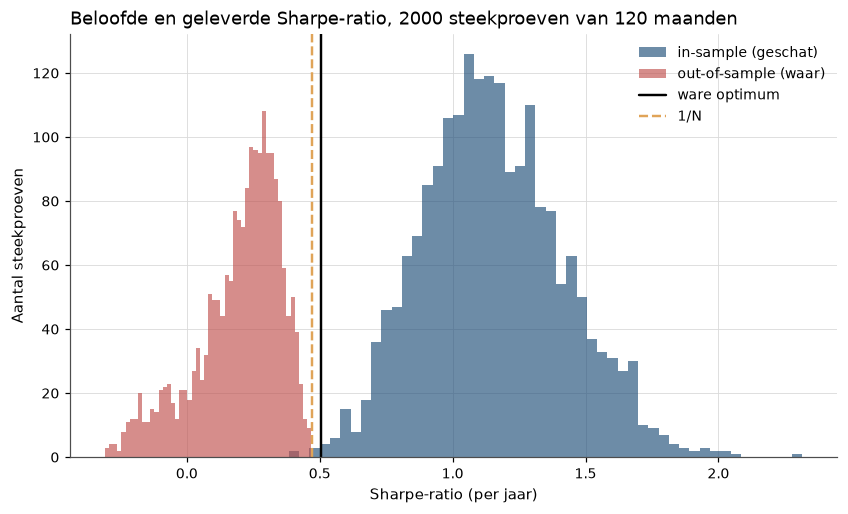

In [8]:
T_plot = 120
shocks = rng.standard_normal((n_sim, T_plot, n_assets)) @ chol.T + mu_true
mu_hat = shocks.mean(axis=1)
dev = shocks - mu_hat[:, None, :]
Sigma_hat = np.einsum("sti,stj->sij", dev, dev) / (T_plot - 1)

sr_oos = oos_sharpe(tangency(mu_hat, Sigma_hat))
sr_ins = np.sqrt(12) * np.sqrt(
    np.einsum("si,sij,sj->s", mu_hat, np.linalg.inv(Sigma_hat), mu_hat)
)

fig, ax = plt.subplots()
ax.hist(sr_ins, bins=50, alpha=0.65, label="in-sample (geschat)")
ax.hist(sr_oos, bins=50, alpha=0.65, label="out-of-sample (waar)")
ax.axvline(float(oos_sharpe(w_star)), color="black", lw=1.6,
           label="ware optimum")
ax.axvline(float(oos_sharpe(w_naive)), color=hap.plotting.COLORS[3], lw=1.6,
           ls="--", label="1/N")
ax.set_xlabel("Sharpe-ratio (per jaar)")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("Beloofde en geleverde Sharpe-ratio, 2000 steekproeven van 120 maanden")
ax.legend()
plt.show()

:::{figure} #cel-markowitz-simulatie
:label: fig-markowitz-simulatie
:width: 90%

Twee verdelingen uit dezelfde tienduizend-en-een steekproeven van tien jaar. De
rechter is wat de optimalisator *belooft*: de in-sample Sharpe-ratio van de
portefeuille die hij op zijn eigen schattingen heeft gebouwd, ruim boven het ware
optimum. De linker is wat hij *levert*: dezelfde gewichten, gewaardeerd onder de
ware momenten, vrijwel altijd onder het ware optimum en meestal onder 1/N. De
afstand tussen de twee verdelingen is geen pech maar bias: de schatter maximeert
mede over zijn eigen fout.
:::

De in-sample verdeling ligt niet alleen hoger, ze ligt *systematisch* hoger,
en de bias groeit met $N/T$. Dat is het resultaat van {cite:t}`JobsonKorkie1980`
in beeld. Wie honderd activa optimaliseert op tien jaar data, rapporteert een
Sharpe-ratio die vrijwel volledig uit schattingsfout bestaat.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Victor DeMiguel, Lorenzo Garlappi en Raman Uppal, *Optimal Versus
Naive Diversification: How Inefficient Is the 1/N Portfolio Strategy?*, Review of
Financial Studies 2009 {cite}`DeMiguelGarlappiUppal2009`, dat op zijn beurt de
waarschuwing van {cite:t}`Michaud1989` kwantificeert.

**Wat.** Hun tabel 3, de out-of-sample Sharpe-ratio's van de gelijkgewogen
portefeuille tegenover de mean-variance-portefeuille met steekproefmomenten,
geschat op een rollend venster van $M = 120$ maanden. Hun conclusie in de
abstract luidt dat van de veertien modellen die zij over zeven datasets
vergelijken, "none is consistently better than the 1/N rule". Gepubliceerde
cijfers uit die tabel (1/N | mv in-sample | mv out-of-sample): S&P-sectoren
$N=11$: 0,1876 | 0,3848 | 0,0794. Internationale indices $N=9$: 0,1277 | 0,2090
| −0,0719. FF-vierfactordataset $N=24$: 0,1753 | 0,5364 | −0,0031. Zij rekenen
bovendien uit hoe lang een schattingsvenster moet zijn voordat mean-variance
1/N verslaat: bij $N=25$ meer dan 3000 maanden, bij $N=50$ meer dan 6000.

**Data hier.** Kenneth French Data Library via `hap.data.french`: de tien
industrieportefeuilles (`"10_Industry_Portfolios"`, value-weighted, maandelijks)
en de 25 size/BM-portefeuilles (`"25_Portfolios_5x5"`), met de risicovrije rente
uit `hap.data.market_monthly()`. Steekproef 1963-07 tot en met het einde van de
snapshot, zodat de industriedataset dezelfde startdatum heeft als bij DGU
(1963-07–2004-11).

**Verschil met het origineel.** DGU's "Industry"-dataset is $N = 11$: tien
industrieën plus de marktportefeuille; wij gebruiken de tien industrieën zonder
de markt, zodat $N = 10$. Hun steekproef eindigt in november 2004, de onze loopt
ruim twintig jaar verder door. Zij rapporteren daarnaast dertien alternatieve
schatters (Bayes-Stein, minimum-variantie met restricties, shrinkage) waarvan wij
alleen de gelijkgewogen, de minimum-variantie- en de
steekproef-mean-variance-portefeuille overnemen. Onze Sharpe-ratio's zijn
maandelijks, net als de hunne.

**Verwachte afwijking.** Het niveau zal afwijken — andere $N$, andere periode,
andere weging — maar de *ordening* moet identiek zijn aan die van DGU:
in-sample mean-variance ver boven 1/N, out-of-sample mean-variance duidelijk
onder 1/N, en de minimum-variantieportefeuille — die $\hat{\boldsymbol{\mu}}$
helemaal niet gebruikt en dus de slechtst geschatte invoer weglaat — minstens zo
goed als 1/N. Draait die ordening om, dan zit er een fout in de code. De schade
moet bovendien met $N$ toenemen, en de scherpste maat daarvoor is het gat tussen
belofte en levering: in-sample mean-variance min out-of-sample mean-variance
hoort bij de 25 portefeuilles duidelijk groter te zijn dan bij de tien
industrieën, net als de hefboom die de optimalisator aangaat. De
out-of-sample steekproef is 757 − 120 = 637 maanden, dus een Sharpe-ratio heeft
hier een standaardfout van ruwweg $1/\sqrt{637} \approx 0{,}040$ per maand:
verschillen kleiner dan ongeveer 0,08 zijn statistisch niet onderscheidbaar, en
alleen het teken, de ordening en de orde van grootte zijn hier informatief.
```

In [9]:
rf = hap_data.market_monthly()["RF"]

def excess_panel(name, start="1963-07"):
    """French portfolio returns in excess of the risk-free rate."""
    raw = hap_data.french(name, "monthly").loc[start:]
    return raw.sub(rf, axis=0).dropna()

industry = excess_panel("10_Industry_Portfolios")
size_bm = excess_panel("25_Portfolios_5x5")

pd.DataFrame(
    {"N": [industry.shape[1], size_bm.shape[1]],
     "maanden": [len(industry), len(size_bm)],
     "start": [industry.index[0].strftime("%Y-%m"), size_bm.index[0].strftime("%Y-%m")],
     "eind": [industry.index[-1].strftime("%Y-%m"), size_bm.index[-1].strftime("%Y-%m")]},
    index=["10 industrieen", "25 size/BM"],
)

,N,maanden,start,eind
10 industrieen,10,757,1963-07,2026-07
25 size/BM,25,757,1963-07,2026-07


Het recept van DGU: op elke maand $t \ge M$ schatten we
$\hat{\boldsymbol{\mu}}$ en $\hat{\boldsymbol{\Sigma}}$ uit de voorgaande
$M = 120$ maanden, vormen de gewichten, en boeken het gerealiseerde rendement van
maand $t+1$. Er komt geen informatie uit de toekomst in de gewichten — dat is de
hele kunst.

In [10]:
def rolling_oos(panel, window=120):
    """Out-of-sample returns of 1/N, sample mean-variance and minimum variance."""
    values, n = panel.to_numpy(), panel.shape[1]
    ones, out = np.ones(n), {"1/N": [], "mean-variance": [], "minimum-variantie": []}

    for t in range(window, len(values)):
        past = values[t - window:t]
        mu_hat, Sigma_hat = past.mean(axis=0), np.cov(past, rowvar=False)

        w_mv = np.linalg.solve(Sigma_hat, mu_hat)
        w_min = np.linalg.solve(Sigma_hat, ones)
        for key, w in [("1/N", ones / n),
                       ("mean-variance", w_mv / w_mv.sum()),
                       ("minimum-variantie", w_min / w_min.sum())]:
            out[key].append(float(values[t] @ w))

    return pd.DataFrame(out, index=panel.index[window:])


oos_industry = rolling_oos(industry)
oos_size_bm = rolling_oos(size_bm)
oos_industry.tail(3).round(4)

,1/N,mean-variance,minimum-variantie
date,,,
2026-05-31,0.0114,0.1049,-0.0156
2026-06-30,-0.0013,-0.0139,-0.0418
2026-07-31,-0.0058,-0.0673,0.0622


In [11]:
def in_sample_sharpe(panel):
    """Monthly maximum Sharpe ratio attainable with full-sample moments."""
    mu_hat, Sigma_hat = panel.mean().to_numpy(), panel.cov().to_numpy()
    return float(np.sqrt(mu_hat @ np.linalg.solve(Sigma_hat, mu_hat)))


def sharpe_table(panel, oos):
    stats = hap.summary_stats(oos, "monthly")
    return pd.DataFrame(
        {
            "gem. (% p.m.)": stats["mean"] * 100,
            "std. (% p.m.)": stats["std"] * 100,
            "Sharpe (p.m.)": stats["mean"] / stats["std"],
            "SE van Sharpe": 1 / np.sqrt(stats["nobs"].astype(float)),
        }
    ).assign(**{"in-sample mv Sharpe (p.m.)": in_sample_sharpe(panel)})


table = pd.concat(
    {"10 industrieen": sharpe_table(industry, oos_industry),
     "25 size/BM": sharpe_table(size_bm, oos_size_bm)}
)
table.round(4)

gem. (% p.m.) std. (% p.m.) Sharpe (p.m.)  \
10 industrieen 1/N                    0.687159      4.346468      0.158096   
               mean-variance          1.167354     14.461444      0.080722   
               minimum-variantie      0.600235      3.632111      0.165258   
25 size/BM     1/N                    0.832888      5.237451      0.159025   
               mean-variance           8.15583     78.644051      0.103706   
               minimum-variantie      0.943517      3.942485       0.23932   

                                  SE van Sharpe  in-sample mv Sharpe (p.m.)  
10 industrieen 1/N                       0.0396                      0.1848  
               mean-variance             0.0396                      0.1848  
               minimum-variantie         0.0396                      0.1848  
25 size/BM     1/N                       0.0396                      0.4022  
               mean-variance             0.0396                      0.4022  
               minimum-variantie         0.0396                      0.4022

Lees de kolom `Sharpe (p.m.)`. Bij de tien industrieportefeuilles haalt de
gelijkgewogen portefeuille 0,158 per maand en de mean-variance-portefeuille
0,081 — de helft. Bij de 25 size/BM-portefeuilles is het 0,159 tegen 0,104. In
beide gevallen verliest de theoretisch optimale portefeuille van de portefeuille
zonder enige theorie — de ordening die het replicatieblok voorspelde, en die van
DGU's tabel 3, waar de FF-vierfactordataset met $N = 24$ een in-sample Sharpe
van 0,5364 belooft en out-of-sample op −0,0031 uitkomt tegenover 0,1753 voor
1/N. Onze out-of-sample mean-variance blijft positief waar die van hen negatief
wordt, wat past bij een twintig jaar langere steekproef.

Het gat tussen belofte en levering groeit zoals voorspeld met $N$. Bij de tien
industrieën belooft de in-sample optimalisatie 0,185 en levert zij 0,081, een
verschil van 0,10; bij de 25 portefeuilles belooft zij 0,402 en levert 0,104, een
verschil van 0,30. De belofte verdrievoudigt met $N$ en de levering niet — dat
is de bias $\E[\hat{S}^2_{\max}] \approx S^2_{\max} + N/T$ in het echt. Eén
eerlijkheid hoort erbij: met een standaardfout van 0,040 is geen van de
afzonderlijke *verschillen* in out-of-sample Sharpe groter dan twee
standaardfouten. Wat de replicatie vaststelt is een consistent teken over twee
datasets, niet een significant verschil in één.

De minimum-variantieportefeuille wint van beide, met 0,165 bij de industrieën en
0,239 bij de 25 portefeuilles. Dat is geen toeval maar de kern van het argument:
haar gewichten $\boldsymbol{\Sigma}^{-1}\mathbf{1}/A$ gebruiken
$\hat{\boldsymbol{\mu}}$ helemaal niet, zodat zij als enige van de drie de
covariantiestructuur benut zonder op geschatte gemiddelden te jagen. Dat is ook
de reden dat "minimum variance" en "risk parity" als productcategorie bestaan en
"maximum Sharpe" niet.

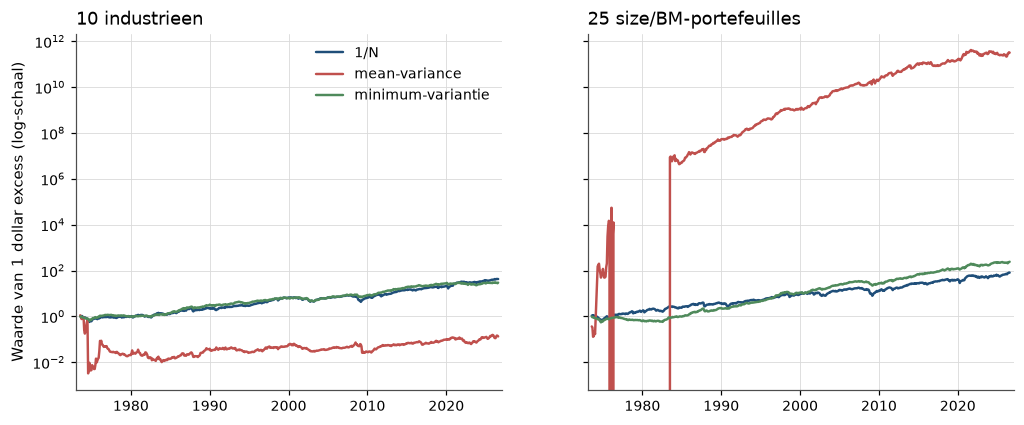

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (title, frame) in zip(axes, [("10 industrieen", oos_industry),
                                     ("25 size/BM-portefeuilles", oos_size_bm)]):
    for column in frame.columns:
        ax.plot(frame.index, (1 + frame[column]).cumprod(), label=column)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Jaar")
    hap.plotting.timeline_axis(ax)
axes[0].set_ylabel("Waarde van 1 dollar excess (log-schaal)")
axes[0].legend()
plt.show()

:::{figure} #cel-markowitz-cumulatief
:label: fig-markowitz-cumulatief
:width: 100%

Cumulatief excess rendement van de drie strategieën, gefinancierd tegen de
risicovrije rente, met een rollend schattingsvenster van 120 maanden. De
mean-variance-portefeuille is niet alleen slechter, ze is ook onrustiger: haar
gewichten springen elke maand mee met de laatste tien jaar aan geschatte
gemiddelden. Dat de gelijkgewogen lijn zo rustig loopt terwijl er geen enkele
schatting in zit, is de kern van het argument van DeMiguel, Garlappi en Uppal.
:::

In [13]:
weights_std = {}
for name, panel in [("10 industrieen", industry), ("25 size/BM", size_bm)]:
    values, n, window = panel.to_numpy(), panel.shape[1], 120
    paths = []
    for t in range(window, len(values)):
        past = values[t - window:t]
        w = np.linalg.solve(np.cov(past, rowvar=False), past.mean(axis=0))
        paths.append(w / w.sum())
    paths = np.array(paths)
    weights_std[name] = {
        "grootste long positie": paths.max(),
        "grootste short positie": paths.min(),
        "gem. bruto exposure (som |w|)": np.abs(paths).sum(axis=1).mean(),
        "gem. maandelijkse turnover": np.abs(np.diff(paths, axis=0)).sum(axis=1).mean(),
    }

pd.DataFrame(weights_std).T.round(3)

,grootste long positie,grootste short positie,gem. bruto exposure (som |w|),gem. maandelijkse turnover
10 industrieen,21.030,-21.219,7.451,2.014
25 size/BM,1158.125,-699.084,72.256,71.678


Hier staat waarom de out-of-sample Sharpe zo slecht is. Bij de tien industrieën
gaat de optimalisator tot ruim 2100% long in één portefeuille tegenover ruim
2100% short in een andere, met een bruto exposure van gemiddeld 7,5 maal het
vermogen en een maandelijkse omzet van tweemaal het vermogen. Bij de 25
portefeuilles ontspoort het volledig: posities tot meer dan honderdduizend
procent, een bruto exposure van gemiddeld 72 maal het vermogen en een
maandelijkse omzet van dezelfde orde — de hele portefeuille wordt elke maand
meermaals omgegooid. Dáár groeit de schade met $N$, ook waar de Sharpe-ratio's
het niet significant laten zien. De optimalisator ziet twee sterk gecorreleerde portefeuilles met een klein
verschil in geschat gemiddelde en concludeert dat daar een bijna risicoloze
arbitrage zit. Dat verschil is ruis, de positie is enorm, en het resultaat is
hefboom op een schattingsfout.

```{tip}
Alle bekende oplossingen komen op hetzelfde neer: weerhoud de optimalisator
ervan $\hat{\boldsymbol{\mu}}$ te volgen. Geen short selling, een bovengrens per
positie, shrinkage van $\hat{\boldsymbol{\mu}}$ richting het gemiddelde
(Bayes-Stein), shrinkage van $\hat{\boldsymbol{\Sigma}}$ richting een
factormodel, of de resampling van {cite:t}`Michaud1989`. Ze zijn beter te
begrijpen als een impliciete prior op $\boldsymbol{\mu}$ dan als een rekentruc —
en de sterkste prior van allemaal, "ik weet niets over verwachte rendementen",
is 1/N.
```

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Meer dan men zich realiseert, en het is bovendien
nooit weerlegd — het is een stelling, geen hypothese. Mean-variance-analyse legt
vast dat het risico van een belegging niet haar eigen volatiliteit is maar haar
covariantie met de rest van de portefeuille; dat de veiligste portefeuille
veiliger kan zijn dan het veiligste activum; dat twee fondsen volstaan om iedere
belegger te bedienen; en dat idiosyncratisch risico gratis weg te diversifiëren
is. Elk van die vier uitspraken is nog steeds waar en zit in de infrastructuur
van elke institutionele belegger ter wereld. De separatiestelling is bovendien
de reden dat indexbeleggen een theoretische rechtvaardiging heeft in plaats van
alleen een kostenargument.

**Waar het breekt.** Niet in de wiskunde maar in de invoer. De replicatie
hierboven laat zien dat de portefeuille die de theorie voorschrijft, geschat op
tien jaar maanddata en toegepast op de volgende maand, een lagere Sharpe-ratio
haalt dan het gelijk verdelen van het geld over dezelfde activa: 0,081 tegen
0,158 per maand bij tien industrieportefeuilles, 0,104 tegen 0,159 bij
vijfentwintig size/BM-portefeuilles. In-sample beloofde diezelfde optimalisatie
0,185 respectievelijk 0,402. Dat is één concreet, meetbaar feit, en het is de
reden dat
{cite:t}`DeMiguelGarlappiUppal2009` becijferden dat je bij $N = 25$ meer dan
drieduizend maanden schattingsvenster nodig hebt — ruim tweehonderdvijftig jaar —
voordat de optimalisatie zich terugverdient. De wortel is motief 1: de
covariantiematrix is redelijk te schatten, de vector van verwachte rendementen
niet, en de optimalisator zet zijn grootste posities precies daar waar hij het
minste weet.

**Risico of vergissing?** Het klassieke motief komt hier in een eigen gedaante
terug, en de vraag is wat het betekent dat 1/N wint. De Chicago-lezing: er valt
niets te optimaliseren omdat de markt al geoptimaliseerd is. Als verwachte
rendementen in evenwicht louter compensatie voor risico zijn, dan zijn de
verschillen tussen activa klein, moeilijk meetbaar en precies groot genoeg om het
verschil in risico te dekken; een strategie die op geschatte
gemiddelden jaagt, jaagt dan per constructie op ruis, en dat 1/N wint is niet
een falen van de theorie maar een bevestiging van de markt. De Yale-lezing: de
verschillen in verwachte rendementen zijn wél echt en wél groot — waarde,
momentum, kleine aandelen — maar ze zijn niet uit tien jaar historische
gemiddelden af te lezen, omdat de prijs er soms naast zit en de geschiedenis dan
juist het verkeerde signaal geeft. In die lezing faalt niet de optimalisatie maar
de *schatter*, en helpt een betere voorspeller van verwachte rendementen wel
degelijk. De data hierboven scheidt de twee niet: beide voorspellen dat
$\hat{\boldsymbol{\mu}}$ uit het verleden onbruikbaar is. Wat ze zou scheiden is
een voorspeller van verwachte rendementen die out-of-sample werkt, en of die
bestaat is het onderwerp van [](#04-20-voorspelbaarheid) en
[](#05-31-portfolio-choice). Het praktijkmotief van Santa-Clara vat het samen:
wat de mean-variance-optimalisator doet is niet risico dragen dat beprijsd is,
maar handelen alsof hij iets weet wat de prijs niet weet.

**Wat er daarna kwam.** Markowitz beschrijft wat één belegger zou moeten doen;
de logische volgende vraag is wat er met de prijzen gebeurt als iedereen het doet
— en die vraag is pas te beantwoorden zodra iemand kan meten wat "de markt"
eigenlijk heeft gedaan. Die meting kwam er in 1964, met de CRSP-tape: zie
[](#02-05-crsp-tape).

## Oefeningen

:::{exercise}
:label: ex-markowitz-1

**De zero-beta-portefeuille.** Werk met het toy-voorbeeld uit deze lecture
($\boldsymbol{\mu}$, $\boldsymbol{\Sigma}$, $A = 128{,}125$, $B = 7{,}0625$,
$C = 0{,}51125$, $D = 15{,}625$).

1. Leid uit [](#eq-markowitz-frontier) af dat de covariantie tussen twee
   frontierportefeuilles met verwachte rendementen $\mu_1$ en $\mu_2$ gelijk is
   aan $\left(A\mu_1\mu_2 - B(\mu_1+\mu_2) + C\right)/D$.
2. Bepaal daaruit het verwachte rendement $\mu_z$ van de portefeuille op de
   frontier die *ongecorreleerd* is met de tangentportefeuille uit het
   toy-voorbeeld ($\mu_{\mathrm{tan}} = 0{,}0822\overline{2}$). Reken het getal
   met de hand uit en controleer het in code.
3. Dat getal heet het zero-beta-rendement. Vergelijk het met de risicovrije
   rente van 2% die de tangentportefeuille genereerde. Wat valt er op, en waarom
   is dat geen toeval?
:::

:::{solution} ex-markowitz-1
:class: dropdown

**(1)** Met $\mathbf{w}_k = \mathbf{g} + \mu_k\mathbf{h}$ uit het bewijs van
[](#thm-markowitz-tweefonds) is
$\Cov(R_1, R_2) = \mathbf{w}_1'\boldsymbol{\Sigma}\mathbf{w}_2
= \mathbf{w}_1'(\lambda_2\boldsymbol{\mu} + \delta_2\mathbf{1})
= \lambda_2\mu_1 + \delta_2$, want $\mathbf{w}_1'\boldsymbol{\mu} = \mu_1$ en
$\mathbf{w}_1'\mathbf{1}=1$. Invullen van
$\lambda_2 = (A\mu_2 - B)/D$ en $\delta_2 = (C - B\mu_2)/D$ geeft
$\left(A\mu_1\mu_2 - B\mu_1 - B\mu_2 + C\right)/D$, symmetrisch in $\mu_1$ en
$\mu_2$ zoals het hoort. Voor $\mu_1 = \mu_2$ reduceert het tot
[](#eq-markowitz-frontier).

**(2)** Nul stellen en oplossen naar $\mu_z$:
$\mu_z = (B\mu_{\mathrm{tan}} - C)/(A\mu_{\mathrm{tan}} - B)$. Met
$\mu_{\mathrm{tan}} = 37/450 = 0{,}0822\overline{2}$ is de teller
$7{,}0625 \cdot 0{,}0822\overline{2} - 0{,}51125 = 0{,}580806 - 0{,}51125
= 0{,}069556$ en de noemer
$128{,}125 \cdot 0{,}0822\overline{2} - 7{,}0625 = 10{,}534722 - 7{,}0625
= 3{,}472222$, dus $\mu_z = 0{,}0200$.

In [14]:
mu_tan = float(w_tan @ mu)
mu_z = (B * mu_tan - C) / (A * mu_tan - B)
w_z = (np.linalg.solve(Sigma, mu) * (A * mu_z - B)
       + np.linalg.solve(Sigma, np.ones(3)) * (C - B * mu_z)) / D

pd.DataFrame(
    {"waarde": [mu_tan, mu_z, float(w_z @ Sigma @ w_tan)]},
    index=["mu van de tangentportefeuille", "zero-beta rendement",
           "covariantie met de tangentportefeuille"],
).round(8)

,waarde
mu van de tangentportefeuille,0.082222
zero-beta rendement,0.020000
covariantie met de tangentportefeuille,-0.000000


**(3)** Het zero-beta-rendement is exact 2%, gelijk aan de risicovrije rente
waarmee we de tangentportefeuille hebben bepaald. Dat is geen toeval:
$\mathbf{w}_{\mathrm{tan}} \propto \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} -
R^{f}\mathbf{1})$ impliceert dat voor elke portefeuille $\mathbf{v}$ met
$\mathbf{v}'\mathbf{1} = 1$ geldt
$\Cov(R_v, R_{\mathrm{tan}}) \propto \mathbf{v}'(\boldsymbol{\mu} - R^{f}\mathbf{1})
= \mu_v - R^{f}$. Nulcovariantie betekent dus $\mu_v = R^{f}$. Deze oefening is
de kern van {cite:t}`Black1972`: ook zonder risicovrij activum bestaat er een
portefeuille die de rol van $R^{f}$ speelt, en het CAPM geldt dan met $\mu_z$ in
plaats van $R^{f}$.
:::

:::{exercise}
:label: ex-markowitz-2

**Hoeveel data is genoeg?** Herhaal de simulatie uit deze lecture, maar varieer
$N$ in plaats van alleen $T$.

1. Bouw dezelfde wereld met $N \in \{5, 10, 25\}$ activa (dezelfde bereiken voor
   $\boldsymbol{\mu}$ en $\sigma$, dezelfde correlatie 0,60). Rapporteer per $N$
   de Sharpe-ratio van 1/N, de mediane out-of-sample Sharpe-ratio van de
   steekproef-mean-variance-portefeuille bij $T = 120$, en het kleinste
   schattingsvenster uit $\{120, 240, 480, 960, 1920, 2880, 3840\}$ waarbij
   mean-variance 1/N overtreft.
2. Vergelijk met de calibratie van {cite:t}`DeMiguelGarlappiUppal2009`: zij
   vinden dat bij $N = 25$ meer dan 3000 maanden nodig is.
3. Verklaar in één zin waarom het benodigde venster met $N$ groeit.
:::

:::{solution} ex-markowitz-2
:class: dropdown

In [15]:
def breakeven(n, horizons=(120, 240, 480, 960, 1920, 2880, 3840), n_sim=200):
    """Median OOS Sharpe at T=120 and the smallest T at which mv beats 1/N."""
    mu_n = np.linspace(0.0040, 0.0080, n)
    sd_n = np.linspace(0.045, 0.065, n)
    corr_n = np.full((n, n), 0.60)
    np.fill_diagonal(corr_n, 1.0)
    Sigma_n = corr_n * np.outer(sd_n, sd_n)
    chol_n = np.linalg.cholesky(Sigma_n)

    def sr(w):
        return np.squeeze(
            np.sqrt(12) * (w @ mu_n)
            / np.sqrt(np.einsum("ij,jk,ik->i", w, Sigma_n, w))
        )

    sr_naive, sr_120, smallest = float(sr(np.full((1, n), 1 / n))), np.nan, np.nan
    for T in horizons:
        draws = rng.standard_normal((n_sim, T, n)) @ chol_n.T + mu_n
        m = draws.mean(axis=1)
        d = draws - m[:, None, :]
        S = np.einsum("sti,stj->sij", d, d) / (T - 1)
        w = np.linalg.solve(S, m[..., None])[..., 0]
        median = float(np.median(sr(w / w.sum(axis=-1, keepdims=True))))
        if T == 120:
            sr_120 = median
        if np.isnan(smallest) and median > sr_naive:
            smallest = T
    return {"Sharpe van 1/N": sr_naive, "mv bij T=120": sr_120,
            "kleinste T": smallest}


pd.DataFrame({n: breakeven(n) for n in [5, 10, 25]}).T.rename_axis("N").round(4)

,Sharpe van 1/N,mv bij T=120,kleinste T
N,,,
5,0.4578,0.2935,2880.0
10,0.4722,0.2297,3840.0
25,0.4814,0.1493,3840.0


**(1)** Bij tien jaar data levert mean-variance 0,294 bij $N = 5$, 0,230 bij
$N = 10$ en 0,149 bij $N = 25$, terwijl 1/N in alle drie de gevallen rond 0,47
blijft: de schade groeit monotoon met $N$ bij vast schattingsvenster. Het
breakeven-venster loopt van 2880 maanden bij $N = 5$ naar 3840 bij $N = 10$ en
$N = 25$; de tussenliggende rasterpunten zijn te grof om de twee laatste te
scheiden, en met tweehonderd herhalingen is de mediaan zelf ook nog onrustig.
**(2)** Bij $N = 25$ komt onze simulatie op 3840 maanden uit — 320 jaar — en dat
is dezelfde orde van grootte als de "meer dan 3000 maanden" van DGU. Dat is
opmerkelijk, want onze wereld is vriendelijker dan de hunne: gelijke correlaties,
een keurige spreiding in $\boldsymbol{\mu}$ en normaal verdeelde rendementen. De
conclusie is dus robuust tegen de details van de calibratie.
**(3)** De bias in de in-sample Sharpe-ratio schaalt met $N/T$, dus om de
schattingsfout per activum constant te houden moet $T$ met $N$ meegroeien. Wie
vijf keer zoveel activa optimaliseert, heeft ongeveer vijf keer zoveel
geschiedenis nodig voor dezelfde kwaliteit — en die geschiedenis bestaat niet.
:::

:::{exercise}
:label: ex-markowitz-3

**De replicatie uitbreiden: shrinkage.** Herhaal de rollende out-of-sample
analyse op de 25 size/BM-portefeuilles, maar krimp $\hat{\boldsymbol{\mu}}$ in
elk venster richting het gemiddelde over alle portefeuilles:
$\tilde{\boldsymbol{\mu}} = \phi\,\hat{\boldsymbol{\mu}} +
(1-\phi)\,\bar{\hat\mu}\,\mathbf{1}$, met $\phi \in \{0, 0{,}25, 0{,}5, 0{,}75, 1\}$.

1. Bereken voor elke $\phi$ de out-of-sample Sharpe-ratio, de gemiddelde bruto
   exposure en de gemiddelde turnover.
2. Bij welke $\phi$ is het resultaat het beste, en wat is de portefeuille bij
   $\phi = 0$?
3. Wat leert dit over de vraag of het probleem bij de optimalisatie of bij de
   invoer zit?
:::

:::{solution} ex-markowitz-3
:class: dropdown

In [16]:
def shrunk_oos(panel, phi, window=120):
    values, n = panel.to_numpy(), panel.shape[1]
    rets, paths = [], []
    for t in range(window, len(values)):
        past = values[t - window:t]
        mu_hat = past.mean(axis=0)
        mu_tilde = phi * mu_hat + (1 - phi) * mu_hat.mean()
        w = np.linalg.solve(np.cov(past, rowvar=False), mu_tilde)
        w = w / w.sum()
        rets.append(float(values[t] @ w))
        paths.append(w)
    rets, paths = np.array(rets), np.array(paths)
    return {
        "Sharpe (p.m.)": rets.mean() / rets.std(ddof=1),
        "bruto exposure": np.abs(paths).sum(axis=1).mean(),
        "turnover": np.abs(np.diff(paths, axis=0)).sum(axis=1).mean(),
    }


pd.DataFrame(
    {phi: shrunk_oos(size_bm, phi) for phi in [0.0, 0.25, 0.5, 0.75, 1.0]}
).T.rename_axis("phi").round(3)

,Sharpe (p.m.),bruto exposure,turnover
phi,,,
0.00,0.239,7.565,0.729
0.25,0.054,29.585,34.738
0.50,0.000,102.469,151.495
0.75,0.031,180.237,277.413
1.00,0.104,72.256,71.678


**(2)** $\phi = 0$ wint met afstand: Sharpe 0,239 tegen 0,104 bij $\phi = 1$,
bij een bruto exposure van 7,6 in plaats van 72 en een turnover van 0,73 in
plaats van 72. Bij $\phi = 0$ is $\tilde{\boldsymbol{\mu}}$ evenredig met
$\mathbf{1}$ en is de portefeuille exact de minimum-variantieportefeuille
$\boldsymbol{\Sigma}^{-1}\mathbf{1}/A$ — de oplossing die geen enkele informatie
over verwachte rendementen gebruikt.

Het tussengebied gedraagt zich echter niet netjes: $\phi = 0{,}5$ geeft een
Sharpe-ratio van vrijwel nul en een bruto exposure van ruim honderd, slechter dan
$\phi = 1$. Dat is geen fout maar een eigenschap van de normalisatie
$\mathbf{w}/\mathbf{w}'\mathbf{1}$. Bij tussenliggende $\phi$ komt de ongenormeerde
som $\mathbf{1}'\boldsymbol{\Sigma}^{-1}\tilde{\boldsymbol{\mu}}$ in sommige
vensters dicht bij nul, en dan explodeert de geschaalde positie. Alleen de twee
uiteinden zijn hier dus goed gedefinieerde strategieën; wie de tussenliggende
gevallen serieus wil gebruiken, moet de restrictie $\mathbf{w}'\mathbf{1} = 1$
vervangen door een doelvolatiliteit.

**(3)** De optimalisatie is niet het probleem: hetzelfde kwadratische programma
met de invoer waarin $\hat{\boldsymbol{\mu}}$ volledig is weggekrompen, levert
het beste resultaat van alles wat in deze lecture is geprobeerd — beter dan 1/N,
beter dan de volledige optimalisatie. De invoer is het probleem, en het meest
waardevolle wat u over $\hat{\boldsymbol{\mu}}$ kunt weten is hoeveel u hem
*niet* moet geloven. Dat is dezelfde les als in [](#00-00-setup), nu met geld
erachter.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->